*Electric Vehicle Charging Demand Dataset*  
Kelompok  3:  
Rr. Tyas Anandyta Susanto (5027261035)  
Arnand Nabiel Zakia (5027261074)  
Muhammad Athar Ghaisan (5027261105)  
SMART CITY

Perkembangan kendaraan listrik dalam konsep smart city membutuhkan sistem pengisian daya yang efisien agar kebutuhan energi dapat dipenuhi dengan baik. Data pengisian kendaraan listrik menarik untuk dianalisis karena terdapat berbagai faktor seperti kepadatan lalu lintas, kapasitas baterai, daya pengisian, lama pengisian, dan energi yang digunakan. Dengan statistik deskriptif, kita dapat melihat gambaran umum pola kebutuhan pengisian kendaraan listrik serta mengetahui seberapa besar variasi dari faktor-faktor tersebut.  
1. Berapa rata-rata energi yang digunakan untuk mengisi kendaraan listrik?  
2. Berapa rata-rata waktu tunggu kendaraan sebelum melakukan pengisian?  
3. Bagaimana kondisi lalu lintas yang paling sering terjadi saat kendaraan melakukan pengisian?  

In [1]:
import pandas as pd

df = pd.read_csv("ev_charging_dataset.csv")
print(df.shape)   # (200, 27)
df[['energy_consumed_kWh', 'charging_duration', 'waiting_time', 'battery_capacity_kWh', 'traffic_density']].head(200)

(8354, 27)


,energy_consumed_kWh,charging_duration,waiting_time,battery_capacity_kWh,traffic_density
0,30.528616,261.673850,12,60,Low
1,41.504507,49.916518,8,100,Low
2,45.016306,54.019568,11,75,Low
3,28.291670,155.773370,9,40,Low
4,55.810835,306.369479,8,75,Low
...,...,...,...,...,...
195,15.349342,19.288790,5,30,Low
196,20.016071,54.589285,15,40,Low
197,19.582783,171.823749,12,30,Low
198,26.669473,234.419176,1,30,Low


setiap baris mewakili satu sesi pengisian kendaraan listrik

| Kolom | Arti | Jenis variabel | Skala | Satuan | Contoh |
| :--- | :--- | :--- | :--- | :--- | :--- |
| energy_consumed_kWh | Jumlah energi listrik yang digunakan kendaraan selama satu sesi pengisian | Kuantitatif kontinu | Rasio | kWh | 35.5 kWh |
| charging_duration| Lama waktu yang dibutuhkan kendaraan untuk melakukan pengisian daya sampai selesai | Kuantitatif kontinu | Rasio | Menit | 45 menit |
| waiting_time | Waktu yang dihabiskan kendaraan untuk menunggu sebelum proses pengisian dimulai | Kuantitatif kontinu | Rasio | Menit | 10 Menit |
| battery_capacity_kWh |Kapasitas total baterai yang dimiliki kendaraan listrik | Kuantitatif kontinu | Rasio |  kWh | 60 Kwh |
| traffic_density | Kondisi kepadatan lalu lintas ketika kendaraan melakukan pengisian daya | Kualitatif | Ordinal |  Low, Medium, High | High

In [5]:
df.info()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   str    
 1   station_id              8354 non-null   str    
 2   location_type           8354 non-null   str    
 3   vehicle_id              8354 non-null   str    
 4   vehicle_type            8354 non-null   str    
 5   arrival_time            8354 non-null   str    
 6   charging_start_time     8354 non-null   str    
 7   charging_end_time       8354 non-null   str    
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   float64
 15

np.int64(0)

In [16]:
kolom1 = df["energy_consumed_kWh"].head(200)
kolom1.mean(), kolom1.median(), kolom1.mode()[0]
kolom1.var(), kolom1.std()
kolom1.quantile(0.25), kolom1.quantile(0.75)

kolom2 = df["charging_duration"].head(200)
kolom2.mean(), kolom2.median(), kolom2.mode()[0]
kolom2.var(), kolom2.std()
kolom2.quantile(0.25), kolom2.quantile(0.75)

kolom3 = df["waiting_time"].head(200)
kolom3.mean(), kolom3.median(), kolom3.mode()[0]
kolom3.var(), kolom3.std()
kolom3.quantile(0.25), kolom3.quantile(0.75)

kolom3 = df["battery_capacity_kWh"].head(200)
kolom3.mean(), kolom3.median(), kolom3.mode()[0]
kolom3.var(), kolom3.std()
kolom3.quantile(0.25), kolom3.quantile(0.75)

df[["energy_consumed_kWh", "charging_duration", "waiting_time", "battery_capacity_kWh"]].head(200).describe()

,energy_consumed_kWh,charging_duration,waiting_time,battery_capacity_kWh
count,200.000000,200.000000,200.00000,200.000000
mean,38.421289,181.792141,10.22000,59.350000
std,19.878524,161.576915,4.65294,24.414295
min,11.178683,14.677128,0.00000,30.000000
25%,22.372480,60.606758,7.00000,40.000000
50%,34.730097,135.525904,10.00000,60.000000
75%,51.537540,258.987917,13.00000,75.000000
max,89.438047,766.611830,22.00000,100.000000


In [15]:
df["traffic_density"].value_counts()
df["traffic_density"].value_counts(normalize=True) * 100

traffic_density
Low       37.514963
High      37.491022
Medium    24.994015
Name: proportion, dtype: float64

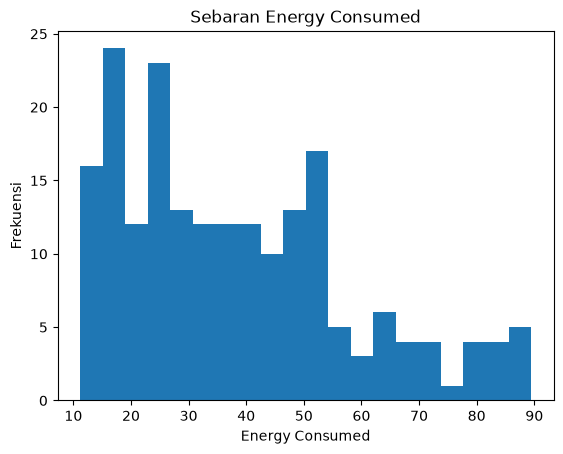

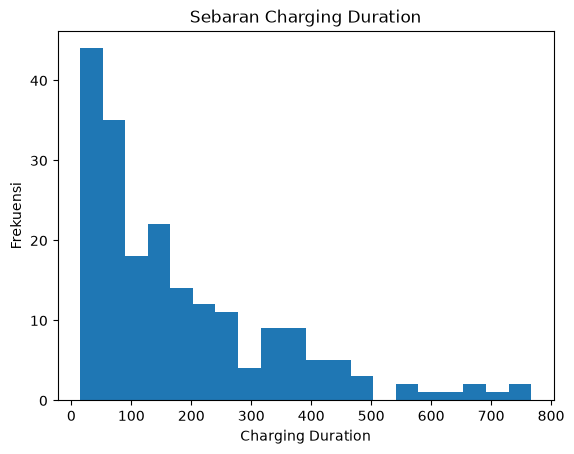

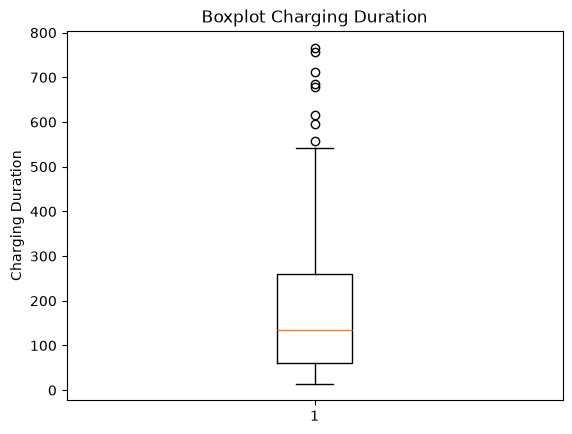

In [22]:
import matplotlib.pyplot as plt

plt.hist(df_sample["energy_consumed_kWh"], bins=20)
plt.title("Sebaran Energy Consumed")
plt.xlabel("Energy Consumed")
plt.ylabel("Frekuensi")
plt.show()

plt.hist(df_sample["charging_duration"], bins=20)
plt.title("Sebaran Charging Duration")
plt.xlabel("Charging Duration")
plt.ylabel("Frekuensi")
plt.show()

plt.boxplot(df_sample["charging_duration"])
plt.title("Boxplot Charging Duration")
plt.ylabel("Charging Duration")
plt.show()

